---
title: Gradient Descent
---

::: {.callout-tip}
## Slides
[Slides](https://docs.google.com/presentation/d/1w5PoGsG-RurZ3QpOfFATrXx5ocZJ6e5JKWoIL05Fydk/edit?slide=id.g3345ec7eb95_0_2#slide=id.g3345ec7eb95_0_2)
::: 

To fit a model, we need a training set {xi,yi}of input/output pairs. We seek param-
eters ϕ for the model f[xi,ϕ] that map the inputs xi to the outputs yi as closely as
possible. To this end, we define a loss function L[ϕ] that returns a single number that
quantifies the mismatch in this mapping. The goal of an optimization algorithm is to
find parametersˆ
ϕthat minimize the loss:

\begin{eqnarray}
 \hat{\boldsymbol\phi} = \mathop{\rm argmin}_{\boldsymbol\phi}\Bigl[L[\boldsymbol\phi]\Bigr].
 \end{eqnarray}

There are many families of optimization algorithms, but the standard methods for train-
ing neural networks are iterative. These algorithms initialize the parameters heuristically
and then adjust them repeatedly in such a way that the loss decreases.

The simplest method in this class is gradient descent. This starts with initial param-
eters ϕ= [ϕ0,ϕ1,...,ϕN ]T and iterates two steps:

**Step 1.** Compute the derivatives of the loss with respect to the parameters:


\begin{eqnarray}
  \frac{\partial L}{\partial \boldsymbol\phi} = \begin{bmatrix}\frac{\partial L}{\partial \phi_{0}} \\[5pt] \frac{\partial L}{\partial \phi_{1}}\\ \vdots \\[5pt] \frac{\partial L}{\partial \phi_{N}}\end{bmatrix}.
 \end{eqnarray}

**Step 2.** Update the parameters according to the rule:

\begin{eqnarray}\label{eq:train_gradient_descent}
  \boldsymbol\phi\longleftarrow\boldsymbol\phi - \alpha \cdot \frac{\partial L}{\partial \boldsymbol\phi},
  \end{eqnarray}

where the positive scalar α determines the magnitude of the change.

The first step computes the gradient of the loss function at the current position. This
determines the uphill direction of the loss function. The second step moves a small
distance α downhill (hence the negative sign). The parameter α may be fixed (in which
case, we call it a learning rate), or we may perform a line search where we try several
values of α to find the one that most decreases the loss.
At the minimum of the loss function, the surface must be flat (or we could improve
further by going downhill). Hence, the gradient will be zero, and the parameters will stop
changing. In practice, we monitor the gradient magnitude and terminate the algorithm
when it becomes too small.

<!-- ```python
# import libraries
import numpy as np
import matplotlib.pyplot as plt 

plt.style.use('dark_background')

# Let's create a simple 1D function
def loss_function(phi):
  return 1- 0.5 * np.exp(-(phi-0.65)*(phi-0.65)/0.1) - 0.45 *np.exp(-(phi-0.35)*(phi-0.35)/0.02)

def draw_function(loss_function,a=None, b=None, c=None, d=None):
  # Plot the function
  phi_plot = np.arange(0,1,0.01);
  fig,ax = plt.subplots()
  ax.plot(phi_plot,loss_function(phi_plot),'r-')
  ax.set_xlim(0,1); ax.set_ylim(0,1)
  ax.set_xlabel(r'$\phi$'); ax.set_ylabel(r'$L(\phi)$')
  if a is not None and b is not None and c is not None and d is not None:
      plt.axvspan(a, d, facecolor='k', alpha=0.2)
      ax.plot([a,a],[0,1],'b-')
      ax.plot([b,b],[0,1],'b-')
      ax.plot([c,c],[0,1],'b-')
      ax.plot([d,d],[0,1],'b-')
  plt.show()


# Draw this function
draw_function(loss_function)

def line_search(loss_function, thresh=.0001, max_iter = 10, draw_flag = False):

    # Initialize four points along the range we are going to search
    a = 0
    b = 0.33
    c = 0.66
    d = 1.0
    n_iter = 0

    # While we haven't found the minimum closely enough
    while np.abs(b-c) > thresh and n_iter < max_iter:
        # Increment iteration counter (just to prevent an infinite loop)
        n_iter = n_iter+1

        # Calculate all four points
        lossa = loss_function(a)
        lossb = loss_function(b)
        lossc = loss_function(c)
        lossd = loss_function(d)

        if draw_flag:
          draw_function(loss_function, a,b,c,d)

        print('Iter %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))

        # Rule #1 If the HEIGHT at point A is less than the HEIGHT at points B, C, and D then move them to they are half
        # as far from A as they start
        # i.e. bring them closer to the original point
        if (lossa < lossb and lossa < lossc and lossa < lossd):
          b = a + (b-a)/2
          c = a + (c-a)/2
          d = a + (d-a)/2
          continue

        # Rule #2 If the HEIGHT at point b is less than the HEIGHT at point c then
        #                     point d becomes point c, and
        #                     point b becomes 1/3 between a and new d
        #                     point c becomes 2/3 between a and new d
        if (lossb < lossc):
          d = c
          c = a + 2*(d-a)/3
          b = a + (d-a)/3
          continue;

        # Rule #3 If the HEIGHT at point c is less than the HEIGHT at point b then
        #                     point a becomes point b, and
        #                     point b becomes 1/3 between new a and d
        #                     point c becomes 2/3 between new a and d
        if(lossc < lossb):
          a = b
          b = a + (d-a)/3
          c = a + 2*(d-a)/3
          continue

    # AVERAGE OF B and C
    soln = (b+c)/2


    return soln

soln = line_search(loss_function, draw_flag=True)
print('Soln = %3.3f, loss = %3.3f'%(soln,loss_function(soln)))
``` -->

## Linear regression example

Consider applying gradient descent to the 1D linear regression model from chapter 2. The
model f[x,ϕ] maps a scalar input xto a scalar output yand has parameters ϕ= [ϕ0,ϕ1]T
, which represent the y-intercept and the slope:

\begin{eqnarray}
  y &=& \mbox{f}[x,\boldsymbol\phi]\nonumber \\
  &=& \phi_{0} + \phi_{1}x.
 \end{eqnarray}

 Given a dataset {xi,yi}containing I input/output pairs, we choose the least squares
loss function:

\begin{eqnarray}\label{eq:train_lr_cost_function}
  L[\boldsymbol\phi] \hspace{0.2cm}= \hspace{0.2cm}\sum_{i=1}^{I} \ell_{i} &=& \sum_{i=1}^{I} \left(\mbox{f}[x_i,\boldsymbol\phi]-y_{i}\right)^{2}\nonumber \\
  &=& \sum_{i=1}^{I} \left(\phi_{0}+\phi_{1}x_{i}-y_{i}\right)^{2},
 \end{eqnarray}

where the term ℓi = (ϕ0 + ϕ1xi−yi)2 is the individual contribution to the loss from the ith training example.

The derivative of the loss function with respect to the parameters can be decomposed
into the sum of the derivatives of the individual contributions:

---

<img src="assets/Chap06/TrainLRMin.svg" style="filter: invert(1);" width="100%">

Gradient descent for the linear regression model. a) Training set of I =
12 input/output pairs {xi, yi}. b) Loss function showing iterations of gradient
descent. We start at point 0 and move in the steepest downhill direction until
we can improve no further to arrive at point 1. We then repeat this procedure.
We measure the gradient at point 1 and move downhill to point 2 and so on. c)
This can be visualized better as a heatmap, where the brightness represents the
loss. After only four iterations, we are already close to the minimum. d) The
model with the parameters at point 0 (lightest line) describes the data very badly,
but each successive iteration improves the fit. The model with the parameters at
point 4 (darkest line) is already a reasonable description of the training data.

---

\begin{eqnarray}\label{eq:train_linear_deriv1}
  \frac{\partial L}{\partial \boldsymbol\phi} = \frac{\partial}{\partial \boldsymbol\phi}\sum_{i=1}^{I} \ell_{i} = \sum_{i=1}^{I} \frac{\partial \ell_{i}}{\partial \boldsymbol\phi},
 \end{eqnarray}

where these are given by:

\begin{eqnarray}\label{eq:train_linear_deriv2}
  \frac{\partial \ell_{i}}{\partial \boldsymbol\phi} = \begin{bmatrix}\frac{\partial \ell_{i}}{\partial \phi_{0}}\\\vspace{-0.2cm}\\\frac{\partial \ell_{i}}{\partial \phi_{1}}\end{bmatrix} = \begin{bmatrix}2(\phi_{0}+\phi_{1}x_{i}-y_{i})\\ \vspace{-0.2cm}\\ 2x_{i}(\phi_{0}+\phi_{1}x_{i}-y_{i})\end{bmatrix}.
 \end{eqnarray}

Figure 6.1 shows the progression of this algorithm as we iteratively compute the
derivatives according to equations 6.6 and 6.7 and then update the parameters using the
rule in equation 6.3. In this case, we have used a line search procedure to find the value
of α that decreases the loss the most at each iteration.

### Gabor model example

Loss functions for linear regression problems (figure 6.1c) always have a single well-
defined global minimum. More formally, they are convex, which means that every chord
(line segment between two points on the surface) lies above the function and does not
intersect it. Convexity implies that wherever we initialize the parameters, we are bound
to reach the minimum if we keep walking downhill; the training procedure can’t fail.
Unfortunately, loss functions for most nonlinear models, including both shallow and
deep networks, are non-convex. Visualizing neural network loss functions is challenging
due to the number of parameters. Hence, we first explore a simpler nonlinear model with
two parameters to gain insight into the properties of non-convex loss functions:


\begin{eqnarray}\label{eq:train_gabor}
 \mbox{f}[x,\boldsymbol\phi] = \sin[\phi_0 + 0.06\cdot\phi_{1}x]\cdot \exp\left(-\frac{(\phi_0+0.06\cdot\phi_{1}x)^2}{32.0}\right).
 \end{eqnarray}

This Gabor model maps scalar input x to scalar output y and consists of a sinusoidal
component (creating an oscillatory function) multiplied by a negative exponential com-
ponent (causing the amplitude to decrease as we move from the center). It has two
parameters ϕ= [ϕ0,ϕ1]T , where ϕ0 ∈R determines the mean position of the function
and ϕ1 ∈R+ stretches or squeezes it along the x-axis (figure 6.2).
Consider a training set of I examples {xi,yi}(figure 6.3). The least squares loss
function for I training examples is defined as:

\begin{eqnarray}
  L[\boldsymbol\phi] = \sum_{i=1}^{I}\left(\mbox{f}[x_{i},\boldsymbol\phi]-y_{i}\right)^2.
 \end{eqnarray}

Once more, the goal is to find the parametersˆϕthat minimize this loss.

<img src="assets/Chap06/TrainGaborModel.svg" style="filter: invert(1);" width="100%">

Gabor model. This nonlinear model maps scalar input x to scalar
output y and has parameters ϕ = [ϕ0, ϕ1]T . It describes a sinusoidal function
that decreases in amplitude with distance from its center. Parameter ϕ0 ∈ R
determines the position of the center. As ϕ0 increases, the function moves left.
Parameter ϕ1 ∈ R+ squeezes the function along the x-axis relative to the center.
As ϕ1 increases, the function narrows. a–c) Model with different parameters.
(Interactive figure)

<img src="assets/Chap06/TrainGaborData.svg" style="filter: invert(1);" align="right" width="40%">

Training data for fitting the
Gabor model. The training dataset contains
28 input/output examples {xi, yi}.
These data were created by uniformly
sampling xi ∈ [−15, 15], passing the
samples through a Gabor model with parameters
ϕ = [0.0, 16.6]T , and adding
normally distributed noise.

### Local minima and saddle points

Figure 6.4 depicts the loss function associated with the Gabor model for this dataset.
There are numerous local minima (cyan circles). Here the gradient is zero, and the loss increases if we move in any direction, but we are not at the overall minimum of the
function. The point with the lowest loss is known as the global minimum and is depicted
by the gray circle.
If we start in a random position and use gradient descent to go downhill, there is no guarantee that we will wind up at the global minimum and find the best parameters
(figure 6.5a). It’s equally or even more likely that the algorithm will terminate in one
of the local minima. Furthermore, there is no way of knowing whether there is a better
solution elsewhere.

<img src="assets/Chap06/TrainGaborMin.svg" style="filter: invert(1);" width="100%">

Loss function for the Gabor model. a) The loss function is non-convex,
with multiple local minima (cyan circles) in addition to the global minimum (gray
circle). It also contains saddle points where the gradient is locally zero, but the
function increases in one direction and decreases in the other. The blue cross is
an example of a saddle point; the function decreases as we move horizontally in
either direction but increases as we move vertically. b–f) Models associated with
the different minima. In each case, there is no small change that decreases the
loss. Panel (c) shows the global minimum, which has a loss of 0.64. (Interactive
figure)

In addition, the loss function contains saddle points (e.g., the blue cross in figure 6.4).
Here, the gradient is zero, but the function increases in some directions and decreases
in others. If the current parameters are not exactly at the saddle point, then gradient
descent can escape by moving downhill. However, the surface near the saddle point is
flat, so it’s hard to be sure that training hasn’t converged; if we terminate the algorithm
when the gradient is small, we may erroneously stop near a saddle point.


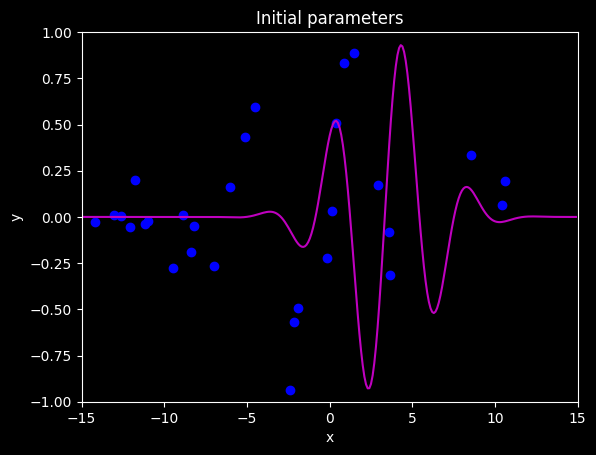

In [13]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

plt.style.use('dark_background')
     

# Let's create our training data of 30 pairs {x_i, y_i}
# We'll try to fit the Gabor model to these data
data = np.array([[-1.920e+00,-1.422e+01,1.490e+00,-1.940e+00,-2.389e+00,-5.090e+00,
                 -8.861e+00,3.578e+00,-6.010e+00,-6.995e+00,3.634e+00,8.743e-01,
                 -1.096e+01,4.073e-01,-9.467e+00,8.560e+00,1.062e+01,-1.729e-01,
                  1.040e+01,-1.261e+01,1.574e-01,-1.304e+01,-2.156e+00,-1.210e+01,
                 -1.119e+01,2.902e+00,-8.220e+00,-1.179e+01,-8.391e+00,-4.505e+00],
                  [-1.051e+00,-2.482e-02,8.896e-01,-4.943e-01,-9.371e-01,4.306e-01,
                  9.577e-03,-7.944e-02 ,1.624e-01,-2.682e-01,-3.129e-01,8.303e-01,
                  -2.365e-02,5.098e-01,-2.777e-01,3.367e-01,1.927e-01,-2.222e-01,
                  6.352e-02,6.888e-03,3.224e-02,1.091e-02,-5.706e-01,-5.258e-02,
                  -3.666e-02,1.709e-01,-4.805e-02,2.008e-01,-1.904e-01,5.952e-01]])
     

# Let's define our model
def model(phi,x):
  sin_component = np.sin(phi[0] + 0.06 * phi[1] * x)
  gauss_component = np.exp(-(phi[0] + 0.06 * phi[1] * x) * (phi[0] + 0.06 * phi[1] * x) / 32)
  y_pred= sin_component * gauss_component
  return y_pred
     

# Draw model
def draw_model(data,model,phi,title=None):
  x_model = np.arange(-15,15,0.1)
  y_model = model(phi,x_model)

  fix, ax = plt.subplots()
  ax.plot(data[0,:],data[1,:],'bo')
  ax.plot(x_model,y_model,'m-')
  ax.set_xlim([-15,15]);ax.set_ylim([-1,1])
  ax.set_xlabel('x'); ax.set_ylabel('y')
  if title is not None:
    ax.set_title(title)
  plt.show()
     

# Initialize the parameters and draw the model
phi = np.zeros((2,1))
phi[0] =  -5     # Horizontal offset
phi[1] =  25     # Frequency
draw_model(data,model,phi, "Initial parameters")

In [ ]:
def compute_loss(data_x, data_y, model, phi):

  y_pred = model(phi,data_x)

  loss = np.sum((y_pred - data_y)**2)

  return loss

loss = compute_loss(data[0,:],data[1,:],model,np.array([[0.6],[-0.2]]))
print('Your loss = %3.3f, Correct loss = %3.3f'%(loss, 16.419))
     

Your loss = 16.419, Correct loss = 16.419


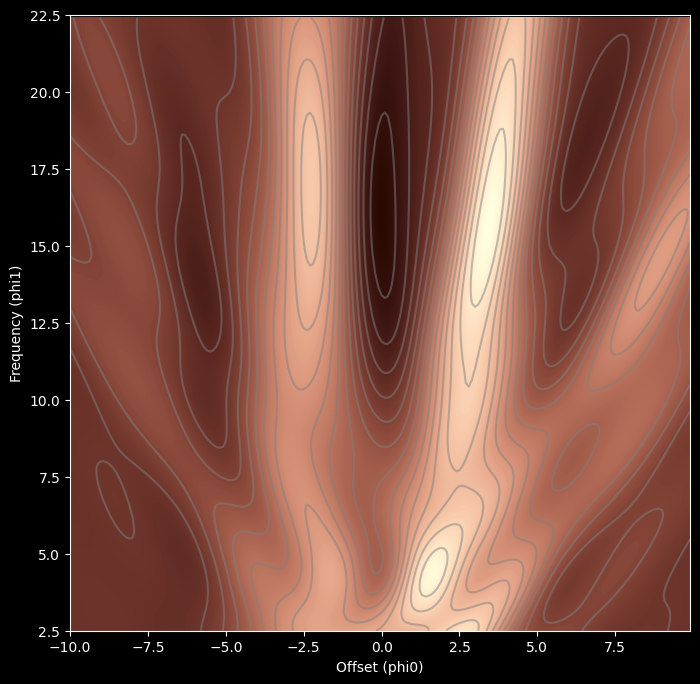

In [24]:
def draw_loss_function(compute_loss, data,  model, phi_iters = None):
  # Define pretty colormap
  my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
  my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
  r = np.floor(my_colormap_vals_dec/(256*256))
  g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
  b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
  my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

  # Make grid of offset/frequency values to plot
  offsets_mesh, freqs_mesh = np.meshgrid(np.arange(-10,10.0,0.1), np.arange(2.5,22.5,0.1))
  loss_mesh = np.zeros_like(freqs_mesh)
  # Compute loss for every set of parameters
  for idslope, slope in np.ndenumerate(freqs_mesh):
     loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[offsets_mesh[idslope]], [slope]]))

  fig,ax = plt.subplots()
  fig.set_size_inches(8,8)
  ax.contourf(offsets_mesh,freqs_mesh,loss_mesh,256,cmap=my_colormap)
  ax.contour(offsets_mesh,freqs_mesh,loss_mesh,20,colors=['#80808080'])
  if phi_iters is not None:
    ax.plot(phi_iters[0,:], phi_iters[1,:],'go-')
  ax.set_ylim([2.5,22.5])
  ax.set_xlabel('Offset (phi0)'); ax.set_ylabel('Frequency (phi1)')
  plt.show()
     

draw_loss_function(compute_loss, data, model)

In [25]:
# These came from writing out the expression for the sum of squares loss and taking the
# derivative with respect to phi0 and phi1. It was a lot of hassle to get it right!
def gabor_deriv_phi0(data_x,data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = cos_component * gauss_component - sin_component * gauss_component * x / 16
    deriv = 2* deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def gabor_deriv_phi1(data_x, data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = 0.06 * data_x * cos_component * gauss_component - 0.06 * data_x*sin_component * gauss_component * x / 16
    deriv = 2*deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def compute_gradient(data_x, data_y, phi):
    dl_dphi0 = gabor_deriv_phi0(data_x, data_y, phi[0],phi[1])
    dl_dphi1 = gabor_deriv_phi1(data_x, data_y, phi[0],phi[1])
    # Return the gradient
    return np.array([[dl_dphi0],[dl_dphi1]])

We can check we got this right using a trick known as finite differences. If we evaluate the function and then change one of the parameters by a very small amount and normalize by that amount, we get an approximation to the gradient, so:

 
 
 
 
 

We can't do this when there are many parameters; for a million parameters, we would have to evaluate the loss function two million times, and usually computing the gradients directly is much more efficient.

In [26]:
# Compute the gradient using your function
gradient = compute_gradient(data[0,:],data[1,:], phi)
print("Your gradients: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))
# Approximate the gradients with finite differences
delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Approx gradients: (%3.3f,%3.3f)"%(dl_dphi0_est,dl_dphi1_est))

Your gradients: (3.344,0.519)
Approx gradients: (3.344,0.519)


Now we are ready to perform gradient descent. We'll need to use our line search routine from Notebook 6.1, which I've reproduced here plus the helper function loss_function_1D that converts from a 2D problem to a 1D problem

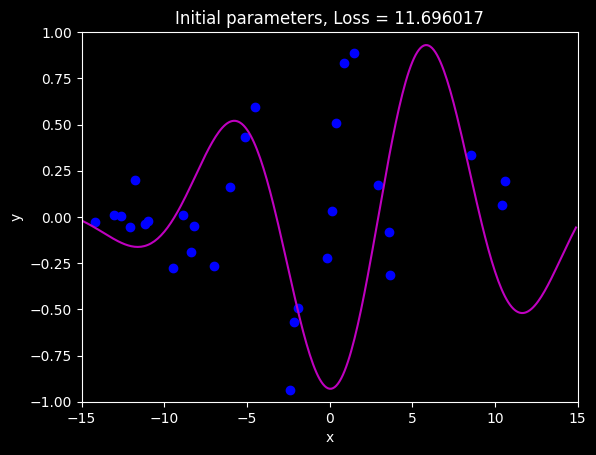

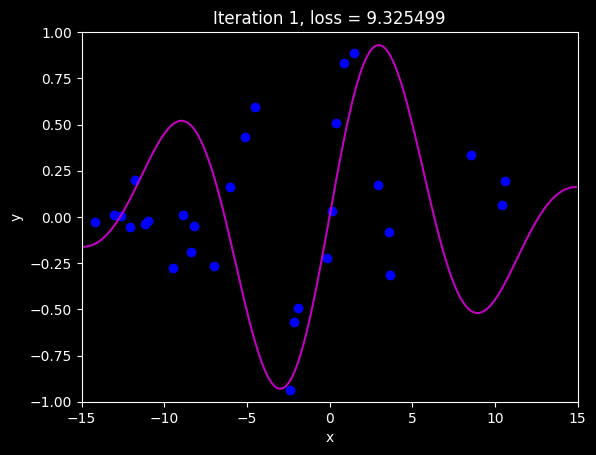

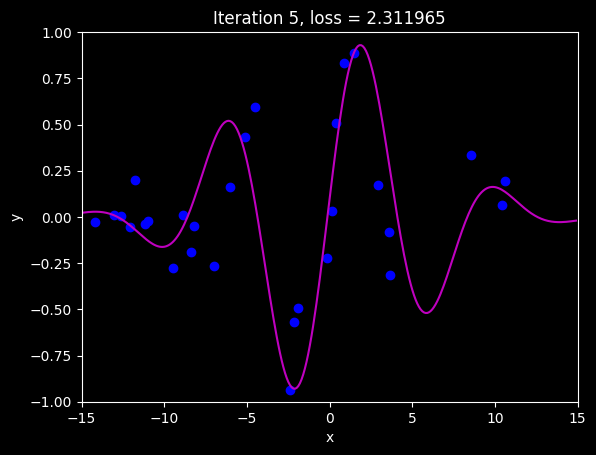

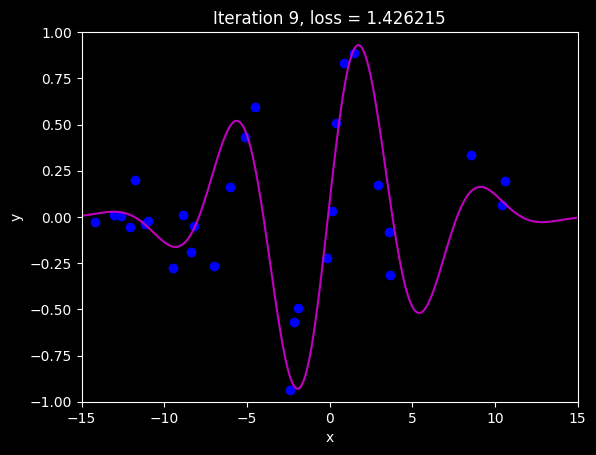

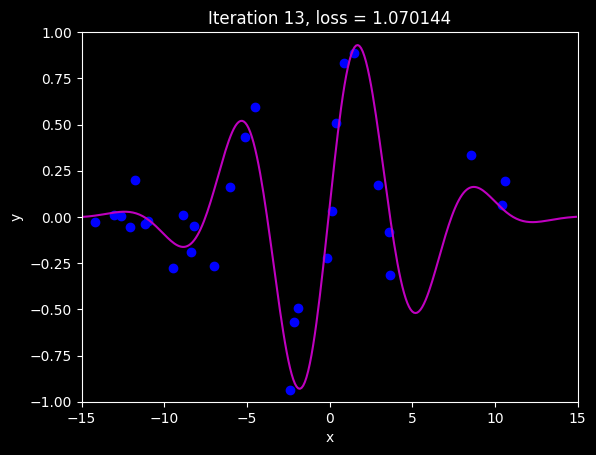

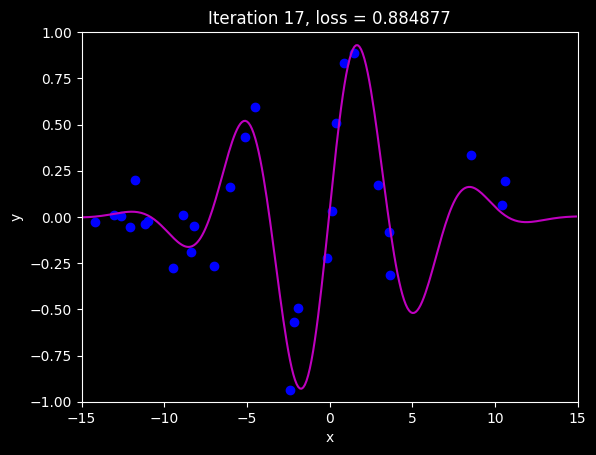

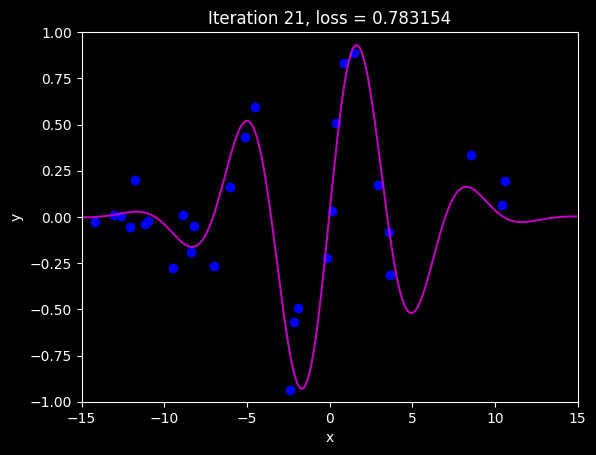

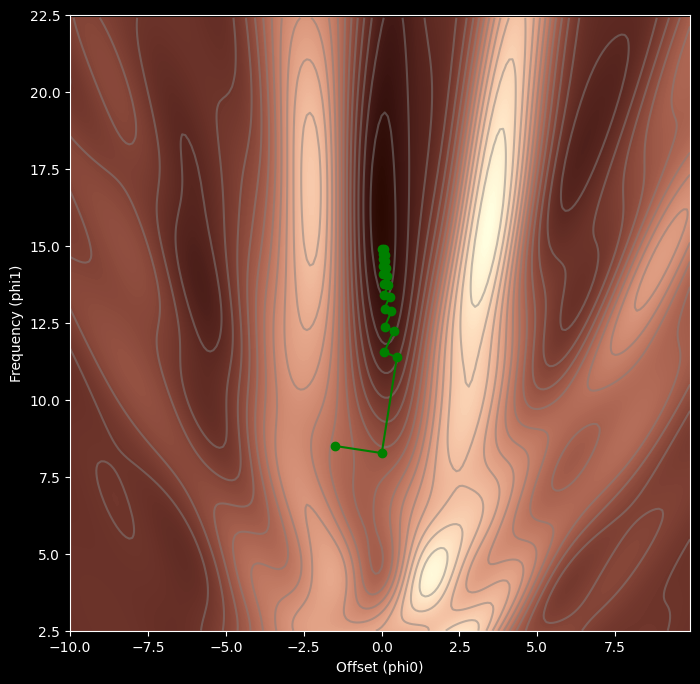

In [27]:
def loss_function_1D(dist_prop, data, model, phi_start, gradient):
  # Return the loss after moving this far
  return compute_loss(data[0,:], data[1,:], model, phi_start+ gradient * dist_prop)

def line_search(data, model, phi, gradient, thresh=.00001, max_dist = 0.1, max_iter = 15, verbose=False):
    # Initialize four points along the range we are going to search
    a = 0
    b = 0.33 * max_dist
    c = 0.66 * max_dist
    d = 1.0 * max_dist
    n_iter = 0

    # While we haven't found the minimum closely enough
    while np.abs(b-c) > thresh and n_iter < max_iter:
        # Increment iteration counter (just to prevent an infinite loop)
        n_iter = n_iter+1
        # Calculate all four points
        lossa = loss_function_1D(a, data, model, phi,gradient)
        lossb = loss_function_1D(b, data, model, phi,gradient)
        lossc = loss_function_1D(c, data, model, phi,gradient)
        lossd = loss_function_1D(d, data, model, phi,gradient)

        if verbose:
          print('Iter %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))
          print('a %f, b%f, c%f, d%f'%(lossa,lossb,lossc,lossd))

        # Rule #1 If point A is less than points B, C, and D then change B,C,D so they are half their current distance from A
        if np.argmin((lossa,lossb,lossc,lossd))==0:
          b = a+ (b-a)/2
          c = a+ (c-a)/2
          d = a+ (d-a)/2
          continue;

        # Rule #2 If point b is less than point c then
        #                     point d becomes point c, and
        #                     point b becomes 1/3 between a and new d
        #                     point c becomes 2/3 between a and new d
        if lossb < lossc:
          d = c
          b = a+ (d-a)/3
          c = a+ 2*(d-a)/3
          continue

        # Rule #2 If point c is less than point b then
        #                     point a becomes point b, and
        #                     point b becomes 1/3 between new a and d
        #                     point c becomes 2/3 between new a and d
        a = b
        b = a+ (d-a)/3
        c = a+ 2*(d-a)/3

    # Return average of two middle points
    return (b+c)/2.0
     

def gradient_descent_step(phi, data,  model):
  # Step 1:  Compute the gradient
  gradient = compute_gradient(data[0,:],data[1,:], phi)
  # Step 2:  Update the parameters -- note we want to search in the negative (downhill direction)
  alpha = line_search(data, model, phi, gradient*-1, max_dist = 2.0)
  phi = phi - alpha * gradient
  return phi
     

# Initialize the parameters
n_steps = 21
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = -1.5
phi_all[1,0] = 8.5

# Measure loss and draw initial model
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Initial parameters, Loss = %f"%(loss))

for c_step in range (n_steps):
  # Do gradient descent step
  phi_all[:,c_step+1:c_step+2] = gradient_descent_step(phi_all[:,c_step:c_step+1],data, model)
  # Measure loss and draw model every 4th step
  if c_step % 4 == 0:
    loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
    draw_model(data,model,phi_all[:,c_step+1], "Iteration %d, loss = %f"%(c_step+1,loss))

draw_loss_function(compute_loss, data, model,phi_all) 